📄 Enter the path of your bank statement PDF:  "C:\Users\prach\OneDrive\Desktop\prachiguptass.pdf"


Failed to import jpype dependencies. Fallback to subprocess.
No module named 'jpype'



⏳ Extracting data from PDF...
✅ PDF successfully converted to CSV → C:\Users\prach\OneDrive\Desktop\prachiguptass.csv

✅ File 'prachiguptass.csv' loaded successfully.

Columns detected: ['Date', 'Narration', 'Chq./Ref.No.', 'Value Dt', 'Withdrawal Amt.', 'Deposit Amt.', 'Closing Balance']

✅ Detected columns — Withdrawal: 'Withdrawal Amt.', Credit: 'Deposit Amt.'

💰 Total Credited: ₹ 1,651.00
💸 Total Debited:  ₹ 2,825.07

--- 💸 TOTAL NET SPENDING PER CATEGORY ---
🔹 Upi-Ram: ₹ 643.00
🔹 Debit Card Annual Fee-Sep-2025...: ₹ 354.00
🔹 Upi-Google India: ₹ 350.90
Food & Dining 🍱: ₹ 341.00
Groceries 🛒: ₹ 316.49
🔹 Upi-Eternal: ₹ 275.68
🔹 Upi-Aanya: ₹ 200.00
🔹 Upi-Ashu-Paytm: ₹ 100.00
🔹 Upi-Neeraj: ₹ 80.00
🔹 Upi-Superhit: ₹ 50.00
🔹 Upi-Manoj Kumar: ₹ 30.00
🔹 Upi-Mr: ₹ 23.00
Travel & Fuel 🚗: ₹ 21.00
🔹 Upi-Anuj Pal-9667874507-3@Ibl-...: ₹ 20.00
🔹 Upi-Ram Singh-9026846334@Ptsbi...: ₹ 20.00

--- 🥇 HIGHEST SPENDING CATEGORY ---
🔹 Upi-Ram: ₹ 643.00


C:\Users\prach\AppData\Local\Temp\ipykernel_15548\677724102.py:146: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  plt.tight_layout()
C:\Users\prach\AppData\Local\Temp\ipykernel_15548\677724102.py:146: UserWarning: Glyph 127857 (\N{BENTO BOX}) missing from current font.
  plt.tight_layout()
C:\Users\prach\AppData\Local\Temp\ipykernel_15548\677724102.py:146: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from current font.
  plt.tight_layout()
C:\Users\prach\AppData\Local\Temp\ipykernel_15548\677724102.py:146: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from current font.
  plt.tight_layout()
C:\Users\prach\anaconda4\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\prach\anaconda4\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127857 (\N{BENTO BOX}) missing from current font.
  fig.canvas

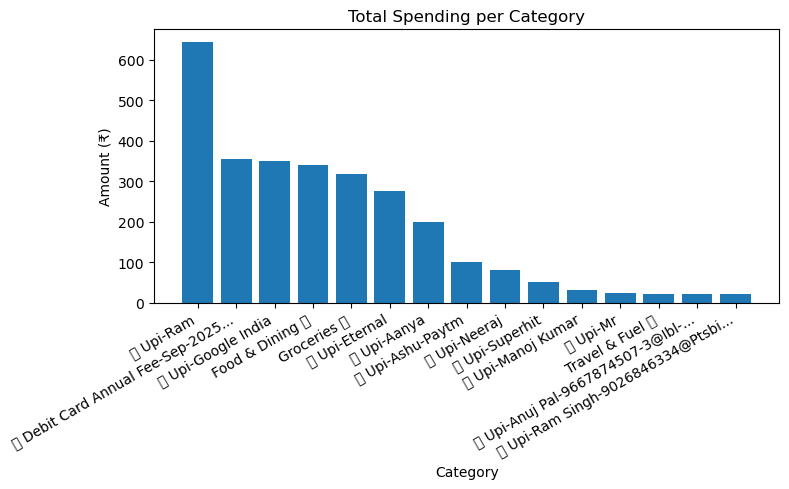

In [1]:
import pandas as pd
import numpy as np
import re
import tabula
import matplotlib.pyplot as plt
import os

# === STEP 1: Ask user for PDF file ===
pdf_path = input("📄 Enter the path of your bank statement PDF: ").strip('"')

if not os.path.exists(pdf_path):
    print("❌ File not found. Please check your path and try again.")
    exit()

print("\n⏳ Extracting data from PDF...")

# === STEP 2: Convert PDF → CSV ===
csv_path = pdf_path.replace('.pdf', '.csv')
try:
    tabula.convert_into(pdf_path, csv_path, output_format="csv", pages='all', guess=True)
    print(f"✅ PDF successfully converted to CSV → {csv_path}\n")
except Exception as e:
    print("❌ PDF extraction failed:", e)
    exit()

# === STEP 3: Load CSV ===
df = pd.read_csv(csv_path)
print(f"✅ File '{os.path.basename(csv_path)}' loaded successfully.\n")
print("Columns detected:", list(df.columns))
print()

# === STEP 4: Auto-detect key columns ===
def detect_column(df, keywords):
    for col in df.columns:
        if any(re.search(k, col.lower()) for k in keywords):
            return col
    return None

def detect_narration_column(df):
    for col in df.columns:
        if re.search(r'narration|description|transaction|details', col.lower()):
            return col
    return None

narration_col = detect_narration_column(df)
withdraw_col = detect_column(df, ['withdraw', 'debit', 'dr'])
credit_col = detect_column(df, ['deposit', 'credit', 'cr'])

if narration_col:
    df.rename(columns={narration_col: 'narration'}, inplace=True)
    narration_col = 'narration'
else:
    print("⚠️ Could not detect narration column automatically.")

if not withdraw_col or not credit_col:
    print("⚠️ Could not automatically detect withdrawal or credit columns.\n")
else:
    print(f"✅ Detected columns — Withdrawal: '{withdraw_col}', Credit: '{credit_col}'\n")
    df.rename(columns={withdraw_col: 'withdrawal_amt', credit_col: 'deposit_amt'}, inplace=True)

# === STEP 5: Clean & prepare data ===
df['withdrawal_amt'] = pd.to_numeric(df['withdrawal_amt'], errors='coerce').fillna(0)
df['deposit_amt'] = pd.to_numeric(df['deposit_amt'], errors='coerce').fillna(0)

# === STEP 6: Clean narration text ===
def clean_narration(text):
    text = str(text).upper().strip()
    text = re.sub(r'DMRC.*', 'DMRC', text)
    text = re.sub(r'ZOMATO.*', 'ZOMATO', text)
    text = re.sub(r'SWIGGY.*', 'SWIGGY', text)
    text = re.sub(r'AMAZON.*', 'AMAZON', text)
    text = re.sub(r'FLIPKART.*', 'FLIPKART', text)
    text = re.sub(r'PHONEPE.*', 'PHONEPE', text)
    text = re.sub(r'GPAY.*', 'GPAY', text)
    text = re.sub(r'PAYTM.*', 'PAYTM', text)
    text = re.sub(r'[-_.,:;0-9]+$', '', text).strip()
    return text

df['Clean_Narration'] = df[narration_col].apply(clean_narration)

# === STEP 7: Categorize transactions ===
def categorize_transaction_base(narration):
    narration = str(narration).upper()
    if any(x in narration for x in ['ZOMATO', 'SWIGGY', 'FOOD', 'RESTAURANT']):
        return 'Food & Dining 🍱'
    elif any(x in narration for x in ['DMRC', 'UBER', 'OLA', 'CAB', 'PETROL', 'FUEL', 'TRAVEL']):
        return 'Travel & Fuel 🚗'
    elif any(x in narration for x in ['AMAZON', 'FLIPKART', 'MYNTRA', 'AJIO', 'SHOP']):
        return 'Online Shopping 🛍️'
    elif any(x in narration for x in ['ELECTRICITY', 'WATER', 'BILL', 'RECHARGE', 'INTERNET']):
        return 'Utilities 💡'
    elif any(x in narration for x in ['INSURANCE', 'SIP', 'MUTUAL FUND', 'GROWW']):
        return 'Investments 📈'
    elif any(x in narration for x in ['BLINKIT', 'BIGBASKET', 'GROCERY', 'MART','ZEPTO']):
        return 'Groceries 🛒'
    else:
        return 'Others 💼'

df['Category'] = df['Clean_Narration'].apply(categorize_transaction_base)

# === STEP 8: Dynamic category naming ===
def create_dynamic_category(narration):
    narration = str(narration).title()
    if len(narration) > 30:
        narration = narration[:30] + '...'
    return f'🔹 {narration}'

df['Category'] = df.apply(
    lambda row: create_dynamic_category(row['Clean_Narration']) 
    if (row['Category'] == 'Others 💼' and row['withdrawal_amt'] > 0)
    else row['Category'],
    axis=1
)

df['Category'] = df['Category'].replace('Others 💼', 'Unclassified Payment 💼')

# === STEP 9: Summary ===
total_credit = df['deposit_amt'].sum()
total_debit = df['withdrawal_amt'].sum()
print(f"💰 Total Credited: ₹ {total_credit:,.2f}")
print(f"💸 Total Debited:  ₹ {total_debit:,.2f}\n")

spending_df = df[df['withdrawal_amt'] > 0].groupby('Category')['withdrawal_amt'].sum().sort_values(ascending=False)

print("--- 💸 TOTAL NET SPENDING PER CATEGORY ---")
if spending_df.empty:
    print("No debit transactions found.")
else:
    for category, amount in spending_df.items():
        print(f"{category}: ₹ {amount:,.2f}")

print("\n--- 🥇 HIGHEST SPENDING CATEGORY ---")
if not spending_df.empty:
    print(f"{spending_df.idxmax()}: ₹ {spending_df.max():,.2f}")
else:
    print("Could not determine the highest spending category.")

# === STEP 10: Visualization ===
if not spending_df.empty:
    plt.figure(figsize=(8,5))
    plt.bar(spending_df.index, spending_df.values)
    plt.title("Total Spending per Category")
    plt.xlabel("Category")
    plt.ylabel("Amount (₹)")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
